# 01_Setup



In [9]:
# ============================================================
# Step 1. Google Drive 연결 및 프로젝트 경로 설정
# ============================================================

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/datamining_project")

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
MODEL_DIR = BASE_DIR / "models"

for p in [DATA_RAW, DATA_PROCESSED, RESULTS_DIR, FIGURES_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_RAW:", DATA_RAW)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODEL_DIR:", MODEL_DIR)

print("\n[파일 존재 확인]")
print("train.csv:", (DATA_RAW / "train.csv").exists())
print("valid.csv:", (DATA_RAW / "valid.csv").exists())
print("test.csv :", (DATA_RAW / "test.csv").exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/datamining_project
DATA_RAW: /content/drive/MyDrive/datamining_project/data/raw
FIGURES_DIR: /content/drive/MyDrive/datamining_project/results/figures
MODEL_DIR: /content/drive/MyDrive/datamining_project/models

[파일 존재 확인]
train.csv: True
valid.csv: True
test.csv : True


# 02_Data_Load

In [10]:
# ============================================================
# Step 1. Train / Valid / Test 데이터 로드
# ============================================================

import pandas as pd
import numpy as np

train_df = pd.read_csv(DATA_RAW / "train.csv")
valid_df = pd.read_csv(DATA_RAW / "valid.csv")
test_df  = pd.read_csv(DATA_RAW / "test.csv")

# 날짜 컬럼 변환
for df in [train_df, valid_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])

print("[데이터 로드 완료]")
print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)

print("\n[컬럼 목록]")
print(train_df.columns.tolist())

display(train_df.head())

[데이터 로드 완료]
train: (44268, 9)
valid: (5580, 9)
test : (5580, 9)

[컬럼 목록]
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'group']


,date,adj_close,close,high,low,open,volume,ticker,group
0,2023-12-12,21594.337891,23300.0,23450.0,23050.0,23150.0,202001,000080.KS,Medium
1,2023-12-13,21594.337891,23300.0,23500.0,23100.0,23350.0,152072,000080.KS,Medium
2,2023-12-14,21640.677734,23350.0,23500.0,23200.0,23450.0,241168,000080.KS,Medium
3,2023-12-15,21408.978516,23100.0,23400.0,23100.0,23350.0,183231,000080.KS,Medium
4,2023-12-18,21501.660156,23200.0,23300.0,22950.0,23100.0,128306,000080.KS,Medium


In [13]:
# ============================================================
# Step 2 Feature_engineering 데이터 로드
# ============================================================


print("[DATA_PROCESSED 경로]")
print(DATA_PROCESSED)

print("\n[processed 폴더 내부 파일 목록]")
for f in os.listdir(DATA_PROCESSED):
    print(f)



train_df = pd.read_csv(DATA_PROCESSED / "train_features.csv")
valid_df = pd.read_csv(DATA_PROCESSED / "valid_features.csv")
test_df  = pd.read_csv(DATA_PROCESSED / "test_features.csv")

# date 컬럼이 있으면 datetime으로 변환
for df in [train_df, valid_df, test_df]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

print("[데이터 로드 완료]")
print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)

print("\n[컬럼 목록]")
print(train_df.columns.tolist())

display(train_df.head())

[DATA_PROCESSED 경로]
/content/drive/MyDrive/datamining_project/data/processed

[processed 폴더 내부 파일 목록]
test_features.csv
train_features.csv
valid_features.csv
[데이터 로드 완료]
train: (42400, 17)
valid: (3807, 17)
test : (3701, 17)

[컬럼 목록]
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'group', 'vol_chg_rate', 'volume_ma20_ratio', 'daily_return', 'volatility_5d', 'drawdown_after_peak_5d', 'upper_shadow_ratio', 'body_ratio', 'upper_shadow_streak_5d']


,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,2024-01-11,20674.576172,21400.0,22150.0,21200.0,22050.0,330021.0,000080.KS,Medium,1.539190,1.827646,-0.029478,0.012567,0.050998,0.105263,0.684211,2.0
1,2024-01-12,21061.017578,21800.0,21850.0,21400.0,21400.0,194748.0,000080.KS,Medium,-0.409892,1.080679,0.018692,0.017191,0.026786,0.111111,0.888889,1.0
2,2024-01-15,21350.847656,22100.0,22150.0,21750.0,21900.0,24583.0,000080.KS,Medium,-0.873770,0.141416,0.013761,0.018892,0.011186,0.125000,0.500000,0.0
3,2024-01-16,21012.712891,21750.0,22100.0,21700.0,22050.0,64781.0,000080.KS,Medium,1.635195,0.392576,-0.015837,0.020116,0.020270,0.125000,0.750000,0.0
4,2024-01-17,20626.271484,21350.0,21800.0,21300.0,21800.0,93005.0,000080.KS,Medium,0.435683,0.579456,-0.018391,0.021222,0.036117,0.000000,0.900000,0.0


# 03_Preprocessing

In [15]:
# ============================================================
# Step 1. 전처리 상태 확인
# ============================================================

print("[Train]")
print("inf 개수 :", np.isinf(train_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", train_df.isna().sum().sum())
print("거래량 0 개수 :", (train_df["volume"] == 0).sum())

print("\n[Valid]")
print("inf 개수 :", np.isinf(valid_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", valid_df.isna().sum().sum())
print("거래량 0 개수 :", (valid_df["volume"] == 0).sum())

print("\n[Test]")
print("inf 개수 :", np.isinf(test_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", test_df.isna().sum().sum())
print("거래량 0 개수 :", (test_df["volume"] == 0).sum())

[Train]
inf 개수 : 0
NaN 개수 : 8
거래량 0 개수 : 0

[Valid]
inf 개수 : 0
NaN 개수 : 4
거래량 0 개수 : 0

[Test]
inf 개수 : 0
NaN 개수 : 2
거래량 0 개수 : 0


In [17]:
# ============================================================
# Step 2. 전체 모델 공통 결측치 제거
# ============================================================

preprocessing_features = [
    "volume_ma20_ratio",
    "vol_chg_rate",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

train_df = (
    train_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

valid_df = (
    valid_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

test_df = (
    test_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

print("===== 결측치 제거 후 =====")
print("train :", train_df.shape)
print("valid :", valid_df.shape)
print("test  :", test_df.shape)

print("\n===== 남은 NaN 개수 =====")
print("train :", train_df[preprocessing_features].isna().sum().sum())
print("valid :", valid_df[preprocessing_features].isna().sum().sum())
print("test  :", test_df[preprocessing_features].isna().sum().sum())

===== 결측치 제거 후 =====
train : (42396, 17)
valid : (3805, 17)
test  : (3700, 17)

===== 남은 NaN 개수 =====
train : 0
valid : 0
test  : 0


# 04_Baseline1_SingleFeature_AnomalyDetection

## Baseline1 모델 확정

In [18]:
# ============================================================
# Step 1. Baseline1 데이터 복사 및 단일 피처 정의
# ============================================================

base1_train = train_df.copy()
base1_valid = valid_df.copy()
base1_test  = test_df.copy()

# Baseline1은 단일 피처만으로 이상치 탐지
# 비정상 거래 => 평소보다 갑자기 거래량이 몰린다는게 직관적인 기준
base1_feature = "volume_ma20_ratio"
# 오늘 거래량 / 최근 20일 평균 거래량

print("Baseline1 anomaly feature:", base1_feature)

print("\n[데이터 크기]")
print("base1_train:", base1_train.shape)
print("base1_valid:", base1_valid.shape)
print("base1_test :", base1_test.shape)

print("\n[단일 피처 기초 통계 - Train 기준]")
display(base1_train[base1_feature].describe())

Baseline1 anomaly feature: volume_ma20_ratio

[데이터 크기]
base1_train: (42396, 17)
base1_valid: (3805, 17)
base1_test : (3700, 17)

[단일 피처 기초 통계 - Train 기준]


,volume_ma20_ratio
count,42396.000000
mean,1.032254
std,1.002065
min,0.000851
25%,0.593645
50%,0.830969
75%,1.159315
max,19.329603


In [19]:
# ============================================================
# Step 2. Train 기준 Z-score 계산
# ============================================================

base1_mean = base1_train[base1_feature].mean()
base1_std = base1_train[base1_feature].std()

print("Train mean:", base1_mean)
print("Train std :", base1_std)

base1_train["base1_z_score"] = (
    base1_train[base1_feature] - base1_mean
) / base1_std

base1_valid["base1_z_score"] = (
    base1_valid[base1_feature] - base1_mean
) / base1_std

base1_test["base1_z_score"] = (
    base1_test[base1_feature] - base1_mean
) / base1_std

print("\n[Z-score 생성 확인]")
display(base1_train[[base1_feature, "base1_z_score"]].head())

print("\n[Z-score 통계]")
print("Train")
display(base1_train["base1_z_score"].describe())

print("Valid")
display(base1_valid["base1_z_score"].describe())

print("Test")
display(base1_test["base1_z_score"].describe())

Train mean: 1.0322535327251865
Train std : 1.0020651087626438

[Z-score 생성 확인]


,volume_ma20_ratio,base1_z_score
0,1.827646,0.793753
1,1.080679,0.048325
2,0.141416,-0.889002
3,0.392576,-0.638359
4,0.579456,-0.451864



[Z-score 통계]
Train


,base1_z_score
count,4.239600e+04
mean,-1.160607e-16
std,1.000000e+00
min,-1.029277e+00
25%,-4.377045e-01
50%,-2.008701e-01
75%,1.267998e-01
max,1.825964e+01


Valid


,base1_z_score
count,3805.000000
mean,0.189116
std,1.055386
min,-0.963830
25%,-0.296302
50%,-0.024179
75%,0.335204
max,17.701905


Test


,base1_z_score
count,3700.000000
mean,0.045976
std,0.909186
min,-1.002807
25%,-0.356625
50%,-0.116900
75%,0.192188
max,14.453319


In [20]:
# ============================================================
# Step 3. Threshold 후보 생성
# ============================================================

base1_threshold_candidates = [
    0.95,
    0.97,
    0.99
]

base1_threshold_results = []

for q in base1_threshold_candidates:

    threshold = base1_train["base1_z_score"].quantile(q)

    anomaly_count = (
        base1_train["base1_z_score"] >= threshold
    ).sum()

    base1_threshold_results.append({
        "quantile": q,
        "threshold": threshold,
        "anomaly_count": anomaly_count
    })

base1_threshold_df = pd.DataFrame(
    base1_threshold_results
)

display(base1_threshold_df)

,quantile,threshold,anomaly_count
0,0.95,1.205821,2120
1,0.97,1.806365,1272
2,0.99,3.981796,424


In [22]:
# ============================================================
# Step 4. Threshold + K 동시 튜닝
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 공통 군집화 Feature
# 세 모델의 군집화 결과를 공정하게 비교하기 위해 동일한 feature set을 사용한다

common_cluster_features = [
    "volume_ma20_ratio",
    "vol_chg_rate",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

base1_k_candidates = range(2, 9)

# Baseline1은 volume_ma20_ratio 단일 피처로 이상치를 탐지한다.
# 이후 군집화 단계에서는 세 모델 간 비교를 공정하게 하기 위해
# Baseline1, Baseline2, Main Model 모두 동일한 common_cluster_features를 사용한다.
base1_cluster_features = common_cluster_features

base1_tuning_results = []

for q in base1_threshold_candidates:

    # 1. train 기준 threshold 계산
    threshold = base1_train["base1_z_score"].quantile(q)

    # 2. train에서 threshold 이상인 이상치만 추출
    base1_tmp_anomaly_train = base1_train[
        base1_train["base1_z_score"] >= threshold
    ].copy()

    # 3. 군집화 입력 데이터
    X_base1 = base1_tmp_anomaly_train[base1_cluster_features].values

    # 4. 스케일링
    base1_scaler = StandardScaler()
    X_base1_scaled = base1_scaler.fit_transform(X_base1)

    for k in base1_k_candidates:

        # 이상치 개수가 k보다 적으면 skip
        if len(X_base1_scaled) <= k:
            continue

        base1_kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = base1_kmeans.fit_predict(X_base1_scaled)

        sil = silhouette_score(X_base1_scaled, labels)

        base1_tuning_results.append({
            "quantile": q,
            "threshold": threshold,
            "anomaly_count": len(base1_tmp_anomaly_train),
            "k": k,
            "silhouette": sil
        })

base1_tuning_df = pd.DataFrame(base1_tuning_results)

display(
    base1_tuning_df.sort_values(
        by="silhouette",
        ascending=False
    ).head(10)
)

,quantile,threshold,anomaly_count,k,silhouette
1,0.95,1.205821,2120,3,0.400459
0,0.95,1.205821,2120,2,0.388882
2,0.95,1.205821,2120,4,0.350731
8,0.97,1.806365,1272,3,0.275437
11,0.97,1.806365,1272,6,0.272823
9,0.97,1.806365,1272,4,0.269532
10,0.97,1.806365,1272,5,0.260834
12,0.97,1.806365,1272,7,0.251834
7,0.97,1.806365,1272,2,0.249106
17,0.99,3.981796,424,5,0.243770


In [ ]:
# 95% k=3 -> 실루엣 점수가 제일 높긴하지만 95%는 살짝 이상한 점수의 애들이 포함돼있을수도
# 97% k=3 모델도 같이 비교

In [23]:
# ============================================================
# Baseline1 Case 1
# 95% + K=3
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

base1_case1_threshold = (
    base1_train["base1_z_score"].quantile(0.95)
)

base1_case1 = base1_train[
    base1_train["base1_z_score"] >= base1_case1_threshold
].copy()

X_case1 = base1_case1[
    common_cluster_features
]

scaler_case1 = StandardScaler()

X_case1_scaled = scaler_case1.fit_transform(
    X_case1
)

kmeans_case1 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

base1_case1["cluster"] = (
    kmeans_case1.fit_predict(X_case1_scaled)
)

print("Case1 Shape")
print(base1_case1.shape)

print("\nCluster Count")
print(
    base1_case1["cluster"]
    .value_counts()
    .sort_index()
)

base1_case1_profile = (
    base1_case1
    .groupby("cluster")[
        common_cluster_features
    ]
    .mean()
    .round(3)
)

display(base1_case1_profile)

Case1 Shape
(2120, 19)

Cluster Count
cluster
0     360
1      10
2    1750
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,7.864,22.936,0.077,0.089,0.104,0.369,0.531,1.708
1,3.309,3.325,0.000,0.000,-0.206,-4.353,6.867,0.600
2,3.321,2.722,0.022,0.033,0.044,0.252,0.602,1.320


In [24]:
# ============================================================
# Baseline1 Case 2
# 97% + K=3
# ============================================================

base1_case2_threshold = (
    base1_train["base1_z_score"].quantile(0.97)
)

base1_case2 = base1_train[
    base1_train["base1_z_score"] >= base1_case2_threshold
].copy()

X_case2 = base1_case2[
    common_cluster_features
]

scaler_case2 = StandardScaler()

X_case2_scaled = scaler_case2.fit_transform(
    X_case2
)

kmeans_case2 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

base1_case2["cluster"] = (
    kmeans_case2.fit_predict(X_case2_scaled)
)

print("Case2 Shape")
print(base1_case2.shape)

print("\nCluster Count")
print(
    base1_case2["cluster"]
    .value_counts()
    .sort_index()
)

base1_case2_profile = (
    base1_case2
    .groupby("cluster")[
        common_cluster_features
    ]
    .mean()
    .round(3)
)

display(base1_case2_profile)

Case2 Shape
(1272, 19)

Cluster Count
cluster
0    862
1    394
2     16
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.291,3.918,0.053,0.045,0.036,0.195,0.657,0.951
1,7.029,20.902,0.018,0.058,0.116,0.500,0.403,2.348
2,5.712,8.440,0.000,0.000,-0.201,-1.673,3.444,0.312


In [ ]:
# ============================================================
# Baseline1 최종 모델 선택
# Threshold = 97%
# K = 3
# ============================================================

"""
Baseline1은 volume_ma20_ratio(거래량/20일 평균 거래량)를 이용하여
단일 피처 기반 이상치 탐지를 수행한다.

Threshold 후보(95%, 97%, 99%)와 K 후보(2~8)를 비교한 결과,
95% + K=3 조합이 가장 높은 Silhouette Score를 기록하였다.

그러나 95% 기준은 전체 데이터의 상위 5%를 모두 이상치로 간주하기 때문에
일반적인 거래량 증가 구간까지 포함될 가능성이 존재한다.

본 프로젝트의 목적은 단순한 거래량 증가 구간이 아니라
비정상적인 거래 패턴을 탐지하는 것이므로,
보다 보수적인 기준인 97% Threshold를 최종 선택하였다.

97% Threshold는 거래량이 극단적으로 증가한 구간만을 이상치로 추출하며,
충분한 이상치 표본(1,272개)을 확보하면서도
Silhouette Score 0.275를 유지하였다.

또한 군집화 단계에서는 Baseline2 및 Main Model과의
공정한 비교를 위해 동일한 common_cluster_features를 사용하였다.

이상치의 순도(anomaly purity)를 높이기 위해
더 보수적인 기준을 선택했다

최종적으로 Baseline1은

1. volume_ma20_ratio 단일 피처로 이상치 탐지
2. 상위 3%(97% Quantile) 이상치를 추출
3. 공통 Feature Set을 이용하여 K=3으로 군집화

하는 구조로 구성하였다.
"""

In [25]:
# ============================================================
# Baseline1 Final Model Training
# Threshold = 97%
# K = 3
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Train 기준 통계량
base1_final_mean = base1_train[base1_feature].mean()
base1_final_std = base1_train[base1_feature].std()

# Train 기준 Threshold
base1_final_threshold = (
    base1_train["base1_z_score"]
    .quantile(0.97)
)

print("Threshold :", base1_final_threshold)

# Train 이상치 추출
base1_final_train = base1_train[
    base1_train["base1_z_score"] >= base1_final_threshold
].copy()

print("Train Anomaly :", base1_final_train.shape)

# Train 군집화 데이터
X_base1_train = (
    base1_final_train[
        common_cluster_features
    ]
)

# Train 기준 Scaler 학습
base1_final_scaler = StandardScaler()

X_base1_train_scaled = (
    base1_final_scaler.fit_transform(
        X_base1_train
    )
)

# Train 기준 KMeans 학습
base1_final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

base1_final_train["cluster"] = (
    base1_final_kmeans.fit_predict(
        X_base1_train_scaled
    )
)

print(
    base1_final_train["cluster"]
    .value_counts()
    .sort_index()
)

Threshold : 1.8063653319371087
Train Anomaly : (1272, 18)
cluster
0    862
1    394
2     16
Name: count, dtype: int64


## Validation Dataset으로 검증


In [27]:
# ============================================================
# Validation Dataset
# ============================================================

base1_valid["base1_z_score"] = (
    base1_valid[base1_feature]
    - base1_final_mean
) / base1_final_std

base1_valid["base1_anomaly"] = (
    base1_valid["base1_z_score"]
    >= base1_final_threshold
).astype(int)

base1_final_valid = (
    base1_valid[
        base1_valid["base1_anomaly"] == 1
    ]
    .copy()
)

print(
    "Valid Anomaly :",
    base1_final_valid.shape
)

print(
    base1_valid["base1_anomaly"]
    .value_counts()
)

Valid Anomaly : (152, 19)
base1_anomaly
0    3653
1     152
Name: count, dtype: int64


In [28]:
# ============================================================
# Validation Cluster Prediction
# ============================================================

X_base1_valid = (
    base1_final_valid[
        common_cluster_features
    ]
)

X_base1_valid_scaled = (
    base1_final_scaler.transform(
        X_base1_valid
    )
)

base1_final_valid["cluster"] = (
    base1_final_kmeans.predict(
        X_base1_valid_scaled
    )
)

print(
    base1_final_valid["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    97
1    53
2     2
Name: count, dtype: int64


In [29]:
# ============================================================
# Validation Cluster Profile
# ============================================================

base1_valid_profile = (
    base1_final_valid
    .groupby("cluster")[
        common_cluster_features
    ]
    .mean()
    .round(3)
)

display(base1_valid_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.463,3.676,0.087,0.058,0.038,0.184,0.686,0.907
1,5.970,9.342,0.028,0.056,0.126,0.480,0.375,1.981
2,6.141,5.924,0.000,0.001,-0.023,-2.435,2.461,0.000


In [30]:
from sklearn.metrics import silhouette_score

base1_valid_silhouette = silhouette_score(
    X_base1_valid_scaled,
    base1_final_valid["cluster"]
)

print(
    "Validation Silhouette :",
    round(base1_valid_silhouette, 4)
)

Validation Silhouette : 0.221


In [ ]:
'''
Train과 Validation 간 성능 차이가 크지 않았으며,
발견된 거래 패턴이 Validation 데이터에서도
일관되게 관찰되었다.

따라서 Baseline1은 특정 기간에만 맞춰진 결과가 아니라
일반화 가능한 거래 패턴을 학습한 것으로 판단하였다.

## Test Dataset으로 최종 검증

In [31]:
# ============================================================
# Baseline1 Test Evaluation
# ============================================================

base1_test["base1_z_score"] = (
    base1_test[base1_feature]
    - base1_final_mean
) / base1_final_std

base1_test["base1_anomaly"] = (
    base1_test["base1_z_score"]
    >= base1_final_threshold
).astype(int)

base1_final_test = (
    base1_test[
        base1_test["base1_anomaly"] == 1
    ]
    .copy()
)

print(
    "Test Anomaly :",
    base1_final_test.shape
)

print(
    base1_test["base1_anomaly"]
    .value_counts()
)

Test Anomaly : (96, 19)
base1_anomaly
0    3604
1      96
Name: count, dtype: int64


In [32]:
# ============================================================
# Test Cluster Prediction
# ============================================================

X_base1_test = (
    base1_final_test[
        common_cluster_features
    ]
)

X_base1_test_scaled = (
    base1_final_scaler.transform(
        X_base1_test
    )
)

base1_final_test["cluster"] = (
    base1_final_kmeans.predict(
        X_base1_test_scaled
    )
)

print(
    base1_final_test["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    59
1    37
Name: count, dtype: int64


In [33]:
from sklearn.metrics import silhouette_score

base1_test_silhouette = silhouette_score(
    X_base1_test_scaled,
    base1_final_test["cluster"]
)

print(
    "Test Silhouette :",
    round(base1_test_silhouette, 4)
)

Test Silhouette : 0.193


In [35]:
print(base1_final_test["cluster"].value_counts().sort_index())

display(
    base1_final_test
    .groupby("cluster")[common_cluster_features]
    .mean()
    .round(3)
)

cluster
0    59
1    37
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.589,4.239,0.103,0.071,0.049,0.176,0.692,0.831
1,5.948,9.103,0.032,0.077,0.130,0.518,0.376,2.297


In [34]:
# ============================================================
# Baseline1 Final Summary
# ============================================================

base1_summary = pd.DataFrame({
    "Dataset": ["Train", "Valid", "Test"],
    "Silhouette": [
        0.275,  # train 값
        base1_valid_silhouette,
        base1_test_silhouette
    ]
})

display(base1_summary)

,Dataset,Silhouette
0,Train,0.275000
1,Valid,0.220973
2,Test,0.193013


In [ ]:
# Test 데이터에서는 Train/Validation에서 관찰된 3개 유형 중 2개 유형만 나타났다.
# 이는 97% Threshold를 적용하면서 상대적으로 약한 거래량 증가 패턴이 제거되었기 때문으로 해석된다
# 결과적으로 Test 데이터에는 거래량 급증을 동반한 강한 상승형과 윗꼬리 반복형의 두 가지 이상 거래 패턴이 주로 관찰되었다.


In [ ]:
# Baseline1은 거래량 비율(volume_ma20_ratio) 단일 변수만을 사용하여 이상치를 탐지하였다.
# Train 데이터에서 최적 Threshold(97%)와 K=3을 선택한 후 Validation 및 Test 데이터에 동일한 기준을 적용하였다.
# Silhouette Score는 Train(0.275), Validation(0.221), Test(0.193)로 점진적으로 감소하였으나 급격한 성능 저하는 관찰되지 않았다.
# 이는 Train 데이터에서 발견한 이상 거래 패턴이 Validation 및 Test 기간에도 일정 수준 유지됨을 의미하며, 특정 기간에 과도하게 맞춰진 모델이 아님을 시사한다.


## Baseline 1 Visualization

### 01_Anomaly Detection Scatter Plot

In [38]:
# 이상치 탐지 결과
# 전체 Train 데이터에서 Volume_ma20_ratio와 daily_return 관계를 보고
# Baseline 1이 어떤 지점을 이상치로 잡았는지 보여줌

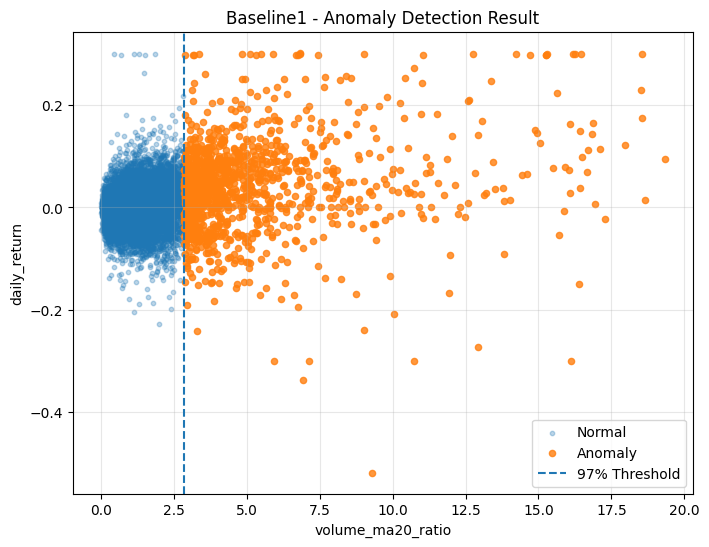

Saved: /content/drive/MyDrive/datamining_project/results/figures/baseline1_01_anomaly_detection_scatter.png


In [40]:
# ============================================================
# Baseline1 Visualization 1
# Anomaly Detection Scatter Plot
# ============================================================

import matplotlib.pyplot as plt

fig_path = FIGURES_DIR / "baseline1_01_anomaly_detection_scatter.png"

# base1_train에 anomaly 컬럼이 없으면 생성
base1_train["base1_anomaly"] = (
    base1_train["base1_z_score"] >= base1_final_threshold
).astype(int)

plt.figure(figsize=(8, 6))

normal_data = base1_train[base1_train["base1_anomaly"] == 0]
anomaly_data = base1_train[base1_train["base1_anomaly"] == 1]

plt.scatter(
    normal_data["volume_ma20_ratio"],
    normal_data["daily_return"],
    alpha=0.3,
    s=10,
    label="Normal"
)

plt.scatter(
    anomaly_data["volume_ma20_ratio"],
    anomaly_data["daily_return"],
    alpha=0.8,
    s=20,
    label="Anomaly"
)

base1_threshold_value = base1_train.loc[
    base1_train["base1_anomaly"] == 1,
    "volume_ma20_ratio"
].min()

plt.axvline(
    x=base1_threshold_value,
    linestyle="--",
    label="97% Threshold"
)

plt.title("Baseline1 - Anomaly Detection Result")
plt.xlabel("volume_ma20_ratio")
plt.ylabel("daily_return")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [ ]:
# x 축 : volume_ma20_ratio
# 1= 평소 거래량 , 2= 평소의 2배 , 5 = 평소의 5배
# y 축 : daily_return
# 당일 수익률 0.1%~ 10%
# 파란점은 97% Threshold 미만 정상 거래
# 주황점은 97% Threshole 이상 비정상 거래

# 대부분 정상 거래는 x < 3 이하에 밀집
# Threshole를 초과한 거래들은 평소 대비 3배 이상의 거래량 증가를 보인다
# 주황점을 보면 수익률이 좋은 점들도 있지만 안좋은 점들도 있다
# -> 비정상적인 거래량


### 02_Cluster Scatter Plot

In [41]:
# 이 그림은 Baseline1이 탐지한 이상치들이 어떤 군집으로 나위었는지 표현
# volume_ma20_ratio 와 vol_chg_rate를 기준으로 보면 거래량 급증 패턴 차이 확인가능

In [91]:
# ============================================================
# Baseline1 Visualization 2
# Cluster Feature Bar Plot
# ============================================================

fig_path = FIGURES_DIR / "baseline1_02_cluster_feature_barplot.png"

base1_train_profile = (
    base1_final_train
    .groupby("cluster")[common_cluster_features]
    .mean()
    .round(3)
)

base1_train_profile.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline1 - Cluster Feature Comparison")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Cluster")

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
display(base1_train_profile)

KeyboardInterrupt: 

In [ ]:
# Cluster 0 (파란색)
#   거래량 증가 : 중간
#   수익률 : 가장 높음
#   변동성 : 보통
#   몸통(body) : 큼
#   해석 : 거래량 증가하면서 실제 주가 상슴
#   이름 : 강한 수급 유입형
# Clueter 1 (주황색)
#   volume_ma20_ratio 최고
#   vol_chg_rate 최고
#   upper_shadow_ratio 높음
#   upper_shadow_streak_5d 최고
#   해석 : 매수세가 강하게 들어왔지만 장중 매도 압력도 강했던 패턴
#   이름 : 차익실현 압력형
# Cluster 2 (초록색)
#   body_ratio 압도적으로 높음
#   drawdown_after_peak_5d 음수
#   cluster 개수 = 16개
#   해석 : 소수의 특수한 거래 패턴
#   거래량은 증가했지만 일반적인 상승 패턴과는 다른 특이 케이스


### 03_Cluster Feature Heatmap

In [50]:
# Train 데이터에서 정의한 Cluster 별 평균 특성을 보여줌

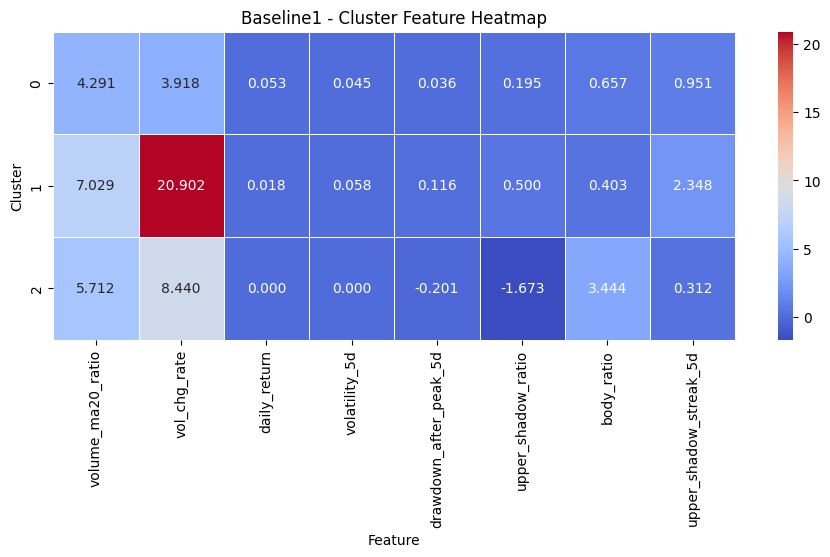

Saved: /content/drive/MyDrive/datamining_project/results/figures/baseline1_03_cluster_feature_heatmap.png


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.291,3.918,0.053,0.045,0.036,0.195,0.657,0.951
1,7.029,20.902,0.018,0.058,0.116,0.500,0.403,2.348
2,5.712,8.440,0.000,0.000,-0.201,-1.673,3.444,0.312


In [51]:
# ============================================================
# Baseline1 Visualization 3
# Cluster Feature Heatmap
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

fig_path = FIGURES_DIR / "baseline1_03_cluster_feature_heatmap.png"

# Train 기준 Cluster 프로파일 생성
base1_train_profile = (
    base1_final_train
    .groupby("cluster")[common_cluster_features]
    .mean()
    .round(3)
)

plt.figure(figsize=(11, 4))

sns.heatmap(
    base1_train_profile,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Baseline1 - Cluster Feature Heatmap")
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

display(base1_train_profile)

In [ ]:
# 이 Heatmap은 Baseline1이 탐지한 이상치들을 K=3으로 군집화한 뒤,
# 각 군집의 평균적인 거래 특성을 비교한 것이다.

# Cluster 0은 거래량 증가와 수익률 상승이 함께 나타나는 강한 수급 유입형,
# Cluster 1은 거래량 폭증과 윗꼬리 반복이 두드러지는 차익실현 압력형,
# Cluster 2는 소수의 특수한 거래 패턴형으로 해석할 수 있다.

### 04_Train / Valid / Test Silhouette Comparison

In [52]:
# 과적합 검증용 시각화 자료

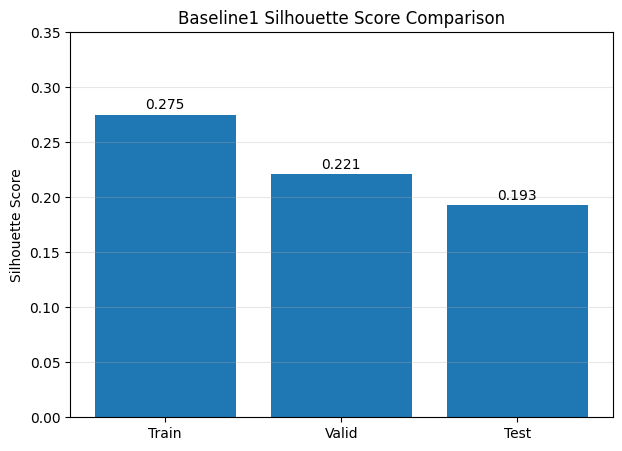

Saved: /content/drive/MyDrive/datamining_project/results/figures/baseline1_04_silhouette_comparison.png


,Dataset,Silhouette
0,Train,0.275000
1,Valid,0.220973
2,Test,0.193013


In [53]:
# ============================================================
# Baseline1 Visualization 4
# Train / Valid / Test Silhouette Comparison
# ============================================================

fig_path = FIGURES_DIR / "baseline1_04_silhouette_comparison.png"

base1_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Valid",
        "Test"
    ],
    "Silhouette": [
        0.275,
        base1_valid_silhouette,
        base1_test_silhouette
    ]
})

plt.figure(figsize=(7,5))

bars = plt.bar(
    base1_summary["Dataset"],
    base1_summary["Silhouette"]
)

plt.title(
    "Baseline1 Silhouette Score Comparison"
)

plt.ylabel(
    "Silhouette Score"
)

plt.ylim(
    0,
    0.35
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.savefig(
    fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", fig_path)

display(base1_summary)

In [ ]:
#Train 데이터에서 최적 Threshold(97%)와 K=3을 선택하였다.

# 이후 동일한 기준을 Validation 및 Test 데이터에 적용하였다.

# Silhouette Score는

# Train : 0.275
# Valid : 0.221
# Test : 0.193

# 으로 점진적으로 감소하였으나 급격한 성능 저하는 관찰되지 않았다.

# 이는 Baseline1이 특정 기간에만 과적합된 모델이 아니라
# Validation 및 Test 데이터에서도 유사한 거래 패턴을 발견할 수 있음을 의미한다.

# 05_Baseline2_KMeans_Only

## baseline2 모델 확정

In [54]:
# ============================================================
# 05_Baseline2_KMeans_Only
# Step 1. Baseline2 데이터 복사 및 Feature 정의
# ============================================================

base2_train = train_df.copy()
base2_valid = valid_df.copy()
base2_test  = test_df.copy()

# Baseline2는 이상치 탐지 없이 전체 데이터를 바로 군집화한다.
# 군집화 feature는 Baseline1, Main Model과 동일하게 common_cluster_features를 사용한다.
base2_cluster_features = common_cluster_features

print("Baseline2 Cluster Features")
print(base2_cluster_features)

print("\n[데이터 크기]")
print("base2_train:", base2_train.shape)
print("base2_valid:", base2_valid.shape)
print("base2_test :", base2_test.shape)

Baseline2 Cluster Features
['volume_ma20_ratio', 'vol_chg_rate', 'daily_return', 'volatility_5d', 'drawdown_after_peak_5d', 'upper_shadow_ratio', 'body_ratio', 'upper_shadow_streak_5d']

[데이터 크기]
base2_train: (42396, 17)
base2_valid: (3805, 17)
base2_test : (3700, 17)


In [55]:
# ============================================================
# 05_Baseline2_KMeans_Only
# Step 2. Train 기준 Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

base2_scaler = StandardScaler()

X_base2_train = base2_train[base2_cluster_features]
X_base2_valid = base2_valid[base2_cluster_features]
X_base2_test  = base2_test[base2_cluster_features]

X_base2_train_scaled = base2_scaler.fit_transform(X_base2_train)
X_base2_valid_scaled = base2_scaler.transform(X_base2_valid)
X_base2_test_scaled  = base2_scaler.transform(X_base2_test)

print("Scaling 완료")
print("Train:", X_base2_train_scaled.shape)
print("Valid:", X_base2_valid_scaled.shape)
print("Test :", X_base2_test_scaled.shape)

Scaling 완료
Train: (42396, 8)
Valid: (3805, 8)
Test : (3700, 8)


In [56]:
# ============================================================
# 05_Baseline2_KMeans_Only
# Step 3. K 후보별 Silhouette Score 비교
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

base2_k_candidates = range(2, 9)
base2_tuning_results = []

for k in base2_k_candidates:

    base2_kmeans_tmp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    base2_train_labels_tmp = base2_kmeans_tmp.fit_predict(
        X_base2_train_scaled
    )

    base2_silhouette_tmp = silhouette_score(
        X_base2_train_scaled,
        base2_train_labels_tmp
    )

    base2_tuning_results.append({
        "k": k,
        "silhouette": base2_silhouette_tmp,
        "inertia": base2_kmeans_tmp.inertia_
    })

base2_tuning_df = pd.DataFrame(base2_tuning_results)

display(
    base2_tuning_df.sort_values(
        by="silhouette",
        ascending=False
    )
)

,k,silhouette,inertia
0,2,0.850387,284016.662278
1,3,0.571472,250340.550054
6,8,0.263183,134265.903412
5,7,0.253582,148152.240795
4,6,0.241743,168416.392051
3,5,0.232710,194214.221875
2,4,0.230639,220422.087216


In [60]:
# ============================================================
# Baseline2
# K = 2
# ============================================================
base2_kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_2 = base2_kmeans_2.fit_predict(
    X_base2_train_scaled
)

pd.Series(labels_2).value_counts()

,count
0,42210
1,186


In [61]:
pd.Series(labels_2).value_counts()

,count
0,42210
1,186


In [62]:
base2_train["cluster"] = labels_2

display(
    base2_train
    .groupby("cluster")[base2_cluster_features]
    .mean()
)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,1.033582,0.423000,0.000739,0.023024,0.044831,0.275331,0.545273,1.452215
1,0.730833,0.128055,0.000000,0.000000,-0.335773,-13.313285,14.147503,0.026882


In [63]:
# ============================================================
# Baseline2 Final Candidate
# K = 3
# ============================================================

from sklearn.cluster import KMeans

base2_final_k = 3

base2_kmeans = KMeans(
    n_clusters=base2_final_k,
    random_state=42,
    n_init=10
)

base2_train["cluster"] = (
    base2_kmeans.fit_predict(
        X_base2_train_scaled
    )
)

print(
    base2_train["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0     2311
1    39899
2      186
Name: count, dtype: int64


In [64]:
# ============================================================
# Cluster Profile
# ============================================================

base2_train_profile = (
    base2_train
    .groupby("cluster")[
        base2_cluster_features
    ]
    .mean()
    .round(3)
)

display(base2_train_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,3.355,5.539,0.050,0.064,0.068,0.265,0.582,1.333
1,0.899,0.127,-0.002,0.021,0.043,0.276,0.543,1.459
2,0.731,0.128,0.000,0.000,-0.336,-13.313,14.148,0.027


In [65]:
from sklearn.metrics import silhouette_score

base2_train_silhouette = silhouette_score(
    X_base2_train_scaled,
    base2_train["cluster"],
    sample_size=5000,
    random_state=42
)

print(
    "Train Silhouette:",
    round(base2_train_silhouette, 4)
)

Train Silhouette: 0.5839


초기 k 탐색 결과
k=2 -> silhouette = 0.85
k=3 -> silhouette = 0.57
정량적 성능만 보면 k=2 일때 가장 높다

하지만 군집 분포를 확인한 결과

k=2                count

Cluster 0   42,210
Cluster 1    186

전체 데이터의 99% 이상이 하나의 군집에 집중되었다
k=2 에서는 정상 데이터 vs 극단적인 이상 데이터 수준의 단순 분리만 이루어졌다
거래 패턴을 세부적으로 해석할 수 있는 군집 구조는 형성되지 않았다.

k=3               count

Cluster 0     2,311

Cluster 1     39,899

Cluster 2     186

일반거래형
거래량 증가형
극단 특이 패턴형
의 세가지 거래 유형으로 구분할 수 있었다.

따라서 Baseline2의 최종 k값은 3으로 결정하였다.

## Validation Dataset으로 검증


In [66]:
# ============================================================
# Baseline2 Validation Prediction
# ============================================================

base2_valid["cluster"] = (
    base2_kmeans.predict(
        X_base2_valid_scaled
    )
)

print(
    base2_valid["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0     420
1    3380
2       5
Name: count, dtype: int64


In [67]:
from sklearn.metrics import silhouette_score

base2_valid_silhouette = silhouette_score(
    X_base2_valid_scaled,
    base2_valid["cluster"],
    sample_size=min(5000, len(base2_valid)),
    random_state=42
)

print(
    "Validation Silhouette:",
    round(base2_valid_silhouette, 4)
)

Validation Silhouette: 0.4838


In [68]:
base2_valid_profile = (
    base2_valid
    .groupby("cluster")[
        base2_cluster_features
    ]
    .mean()
    .round(3)
)

display(base2_valid_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,2.770,2.389,0.058,0.070,0.065,0.222,0.604,1.174
1,1.030,0.082,-0.002,0.025,0.046,0.243,0.476,1.312
2,0.714,-0.250,0.000,0.000,-0.337,-6.919,7.484,0.000


## Test Dataset으로 최종 검증

In [69]:
# ============================================================
# Baseline2 Test Prediction
# ============================================================

base2_test["cluster"] = (
    base2_kmeans.predict(
        X_base2_test_scaled
    )
)

print(
    base2_test["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0     481
1    3218
2       1
Name: count, dtype: int64


In [70]:
base2_test_silhouette = silhouette_score(
    X_base2_test_scaled,
    base2_test["cluster"],
    sample_size=min(5000, len(base2_test)),
    random_state=42
)

print(
    "Test Silhouette:",
    round(base2_test_silhouette, 4)
)

Test Silhouette: 0.4569


In [71]:
base2_test_profile = (
    base2_test
    .groupby("cluster")[
        base2_cluster_features
    ]
    .mean()
    .round(3)
)

display(base2_test_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,2.065,1.601,0.062,0.082,0.080,0.262,0.529,1.233
1,0.931,0.069,-0.005,0.030,0.062,0.248,0.477,1.302
2,0.379,-0.403,0.000,0.000,-0.192,-10.370,10.656,0.000


Baseline 2 모델 해석

Cluster 1 (대다수)

Train : 39899개

Valid : 3380개

Test : 3218개

특징
volume_ma20_ratio ≈ 1
daily_return ≈ 0

-> 일반 거래형

Cluter 0

Train : 2311개

Valid : 420개

Test : 481개

특징

거래량 증가

수익률 증가

변동성 증가

-> 거래량 증가형

Cluster 2

Train : 186개

Valid : 5개

Test : 5개

특징

body_ratio 매우 크다

upper_shadow_ratio 극단값

-> 극단 특이 패턴형

Baseline2는 이상치 탐지 없이 전체 데이터를 직접 군집화했음에도
Validation 및 Test 데이터에서 유사한 군집 구조를 유지하였다

여기서 Main Model이 필요한 이유는 Baseline2 는 분류 수준이 낮음

정상, 약간 특이, 엄청 특이 수준의 분류만 이루어짐

반면 Main Model은 Isolation Forest + DBSCAN + KMeans 를 써서

실제 이상 거래만 선별한 뒤 그 안에서 패턴을 세분화한

# 06_Main_Model

## Main_model version 1 : Isolation Forest + DBSCAN + KMeans


In [72]:
# ============================================================
# Step1. Feature 정의
# ============================================================

main_cluster_features = [
    "volume_ma20_ratio",
    "vol_chg_rate",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]



In [73]:
# ============================================================
# Step1-1. 데이터 copy
# ============================================================

main_train = train_df.copy()
main_valid = valid_df.copy()
main_test  = test_df.copy()

print(main_train.shape)
print(main_valid.shape)
print(main_test.shape)

(42396, 17)
(3805, 17)
(3700, 17)


In [74]:
# ============================================================
# Main Model
# Step 2. Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

main_scaler = StandardScaler()

X_main_train = main_train[main_cluster_features]
X_main_valid = main_valid[main_cluster_features]
X_main_test  = main_test[main_cluster_features]

X_main_train_scaled = (
    main_scaler.fit_transform(X_main_train)
)

X_main_valid_scaled = (
    main_scaler.transform(X_main_valid)
)

X_main_test_scaled = (
    main_scaler.transform(X_main_test)
)

print(X_main_train_scaled.shape)

(42396, 8)


In [75]:
# ============================================================
# Main Model
# Step 3. Isolation Forest Score
# ============================================================

from sklearn.ensemble import IsolationForest

main_iforest = IsolationForest(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

main_iforest.fit(
    X_main_train_scaled
)

main_train["if_score"] = (
    -main_iforest.decision_function(
        X_main_train_scaled
    )
)

main_train["if_score"].describe(
    percentiles=[0.95,0.97,0.99]
)

,if_score
count,42396.000000
mean,-0.092789
std,0.057585
min,-0.153084
50%,-0.110834
95%,0.024194
97%,0.074197
99%,0.154190
max,0.271207


In [76]:
# ============================================================
# Main Model
# Step 4. IF Threshold Candidate
# ============================================================

main_threshold_candidates = [
    0.024194,   # 95%
    0.074197,   # 97%
    0.154190    # 99%
]

for threshold in main_threshold_candidates:

    anomaly_count = (
        main_train["if_score"] >= threshold
    ).sum()

    print(
        f"Threshold={threshold:.6f}",
        "Anomaly Count=",
        anomaly_count
    )

Threshold=0.024194 Anomaly Count= 2120
Threshold=0.074197 Anomaly Count= 1272
Threshold=0.154190 Anomaly Count= 424


In [77]:
# ============================================================
# Main Model
# Step 5. IF(97%) + DBSCAN
# ============================================================

from sklearn.cluster import DBSCAN

main_if_97 = main_train[
    main_train["if_score"] >= 0.074197
].copy()

print(
    "IF 97% Count:",
    len(main_if_97)
)

X_if97 = main_scaler.transform(
    main_if_97[main_cluster_features]
)

main_dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

main_if_97["dbscan_cluster"] = (
    main_dbscan.fit_predict(X_if97)
)

print(
    main_if_97["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

IF 97% Count: 1272
dbscan_cluster
-1    1262
 0      10
Name: count, dtype: int64


In [78]:
# ============================================================
# Main Model
# DBSCAN EPS Tuning
# ============================================================

from sklearn.cluster import DBSCAN
import pandas as pd

main_dbscan_results = []

eps_candidates = [
    0.8,
    1.0,
    1.2,
    1.5,
    2.0,
    2.5,
    3.0
]

for eps in eps_candidates:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_if97)

    cluster_count = len(
        set(labels)
    ) - (1 if -1 in labels else 0)

    noise_count = (
        labels == -1
    ).sum()

    noise_ratio = (
        noise_count / len(labels)
    )

    main_dbscan_results.append({

        "eps": eps,

        "cluster_count": cluster_count,

        "noise_count": noise_count,

        "noise_ratio": round(
            noise_ratio,
            4
        )

    })

    print("\n===================")
    print(f"EPS = {eps}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

main_dbscan_results = pd.DataFrame(
    main_dbscan_results
)

display(main_dbscan_results)


EPS = 0.8
-1    1262
 0      10
Name: count, dtype: int64

EPS = 1.0
-1    1119
 0      19
 1      14
 2     120
Name: count, dtype: int64

EPS = 1.2
-1    879
 0     74
 1     34
 2     15
 3      9
 4     32
 5     10
 6    203
 7     16
Name: count, dtype: int64

EPS = 1.5
-1    672
 0    135
 1     16
 2    176
 3     19
 4    254
Name: count, dtype: int64

EPS = 2.0
-1    399
 0    392
 1     10
 2    202
 3    269
Name: count, dtype: int64

EPS = 2.5
-1    208
 0    566
 1    212
 2     15
 3    271
Name: count, dtype: int64

EPS = 3.0
-1    116
 0    917
 1    223
 2     16
Name: count, dtype: int64


,eps,cluster_count,noise_count,noise_ratio
0,0.8,1,1262,0.9921
1,1.0,3,1119,0.8797
2,1.2,8,879,0.6910
3,1.5,5,672,0.5283
4,2.0,4,399,0.3137
5,2.5,4,208,0.1635
6,3.0,3,116,0.0912


DBSCAN의 eps 값을 0.8~3.0 범위에서 탐색하였다.

eps가 너무 작은 경우 대부분의 이상치가 노이즈로 분류되었고, eps가 너무 큰 경우 거의 모든 이상치가 군집으로 묶여 DBSCAN의 의미가 감소하였다.

본 연구에서는 군집 수와 노이즈 비율의 균형을 고려하여 eps=1.5를 최종 선택하였다.

eps=1.5에서는 5개의 이상치 군집과 약 53%의 노이즈가 관찰되어, Isolation Forest가 탐지한 이상치 중에서도 실제로 유사한 패턴을 가진 이상치 그룹을 효과적으로 구분할 수 있었다

In [79]:
main_dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

labels = main_dbscan.fit_predict(X_if97)

main_if_97["dbscan_cluster"] = labels

main_dbscan_data = main_if_97[
    main_if_97["dbscan_cluster"] != -1
].copy()

print(main_dbscan_data.shape)
print(main_dbscan_data["dbscan_cluster"].value_counts())

(600, 19)
dbscan_cluster
4    254
2    176
0    135
3     19
1     16
Name: count, dtype: int64


Isolation Forest가 탐지한 이상치 중에서도 실제로 유사한 패턴을 보이는 이상치만 DBSCAN을 통해 선별하였다.

In [80]:
# ============================================================
# Main Model
# Step 6. KMeans Tuning
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_main_dbscan = main_scaler.transform(
    main_dbscan_data[main_cluster_features]
)

main_k_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_main_dbscan
    )

    sil = silhouette_score(
        X_main_dbscan,
        labels
    )

    main_k_results.append({
        "k": k,
        "silhouette": sil
    })

main_k_results = pd.DataFrame(
    main_k_results
)

display(
    main_k_results.sort_values(
        "silhouette",
        ascending=False
    )
)

,k,silhouette
1,3,0.569114
2,4,0.539219
5,7,0.516460
4,6,0.515372
6,8,0.489965
0,2,0.485685
3,5,0.472203


DBSCAN을 통해 선별된 600개의 이상 거래 데이터를 대상으로 K=2~8 범위의 KMeans 군집화를 수행하였다.

Silhouette Score를 비교한 결과 K=3에서 가장 높은 값(0.569)을 기록하였다.

따라서 본 연구에서는 K=3을 최종 군집 수로 선택하였다.

이는 DBSCAN을 통해 유사한 이상 거래 패턴만 선별한 이후, 다시 세부 유형으로 분류한 결과로 해석할 수 있다.

In [81]:
# ============================================================
# Main Model Final
# K = 3
# ============================================================

main_final_k = 3

main_kmeans = KMeans(
    n_clusters=main_final_k,
    random_state=42,
    n_init=10
)

main_dbscan_data["cluster"] = (
    main_kmeans.fit_predict(
        X_main_dbscan
    )
)

print(
    main_dbscan_data["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    174
1    254
2    172
Name: count, dtype: int64


In [82]:
main_train_profile = (
    main_dbscan_data
    .groupby("cluster")[main_cluster_features]
    .mean()
    .round(3)
)

display(main_train_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.810,0.190,0.00,0.000,-0.289,-8.013,8.505,0.000
1,0.976,0.138,0.00,0.000,0.280,0.508,11.402,2.937
2,4.222,5.366,0.07,0.064,0.059,0.173,0.737,1.116


Cluster 2 (174개)

volume_ma20_ratio = 4.22,
vol_chg_rate = 5.37,
daily_return = 0.07,
volatility = 0.064

특징

거래량 급증,
거래량 변화율 급증,
수익률 상승,
변동성 증가

이름 : 강한 수급 유입형

Cluster 1 (254개)

upper_shadow_ratio = 0.508,
body_ratio = 11.402,
upper_shadow_streak_5d = 2.937

특징

윗꼬리 반복,
장중 매도압력 존재

이름 : 차익실현 압력형

Cluster 0 (172개)

drawdown_after_peak_5d = -0.289,
upper_shadow_ratio = -8.013,
body_ratio = 8.505

특징

일반 패턴과 매우 다름

이름 : 특수 거래 패턴

Baseline1은 거래량 중심의 이상 거래를 탐지하였다.

Baseline2는 전체 데이터 군집화를 수행하였으나 정상 거래와 극단치를 분리하는 수준에 머물렀다.

Main Model은 Isolation Forest와 DBSCAN을 결합하여 실제 이상 거래만 선별한 후 세부 패턴을 군집화하였다.

### Vaildation Dataset으로 검증


In [92]:
# ============================================================
# Main Model Validation - Correct Version
# IF threshold 적용 → KMeans predict
# DBSCAN은 Train 정제용으로만 사용
# ============================================================

from sklearn.metrics import silhouette_score

# 1. Validation IF score 계산
main_valid["if_score"] = -main_iforest.decision_function(
    X_main_valid_scaled
)

# 2. Train에서 정한 IF threshold 그대로 사용
main_final_if_threshold = 0.074197

main_valid["if_anomaly"] = (
    main_valid["if_score"] >= main_final_if_threshold
).astype(int)

print("[Validation IF anomaly count]")
print(main_valid["if_anomaly"].value_counts())

# 3. IF 이상치만 추출
main_valid_final = main_valid[
    main_valid["if_anomaly"] == 1
].copy()

print("Validation IF anomaly shape:", main_valid_final.shape)

# 4. Train scaler로 transform
X_main_valid_final = main_scaler.transform(
    main_valid_final[main_cluster_features]
)

# 5. Train에서 학습한 KMeans로 cluster predict
main_valid_final["cluster"] = main_kmeans.predict(
    X_main_valid_final
)

print("\n[Validation cluster count]")
print(
    main_valid_final["cluster"]
    .value_counts()
    .sort_index()
)

# 6. Validation silhouette
main_valid_silhouette = silhouette_score(
    X_main_valid_final,
    main_valid_final["cluster"]
)

print(
    "\nValidation Silhouette:",
    round(main_valid_silhouette, 4)
)

# 7. Validation cluster profile
main_valid_profile = (
    main_valid_final
    .groupby("cluster")[main_cluster_features]
    .mean()
    .round(3)
)

display(main_valid_profile)

[Validation IF anomaly count]
if_anomaly
0    3665
1     140
Name: count, dtype: int64
Validation IF anomaly shape: (140, 19)

[Validation cluster count]
cluster
0     14
1      2
2    124
Name: count, dtype: int64

Validation Silhouette: 0.1527


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.577,-0.263,0.000,0.000,-0.245,-5.188,5.661,0.000
1,2.638,2.163,-0.150,0.063,0.457,-0.437,1.302,0.500
2,4.335,6.124,0.048,0.097,0.119,0.029,0.812,1.056


In [104]:
# ============================================================
# Main V1 Test
# ============================================================

main_test["if_score"] = (
    -main_iforest.decision_function(
        X_main_test_scaled
    )
)

main_test["if_anomaly"] = (
    main_test["if_score"] >= 0.074197
).astype(int)

print(
    main_test["if_anomaly"]
    .value_counts()
)

main_test_final = (
    main_test[
        main_test["if_anomaly"] == 1
    ]
    .copy()
)

print(
    "Test IF anomaly:",
    main_test_final.shape
)

X_main_test_final = (
    main_scaler.transform(
        main_test_final[
            main_cluster_features
        ]
    )
)

main_test_final["cluster"] = (
    main_kmeans.predict(
        X_main_test_final
    )
)

print(
    main_test_final["cluster"]
    .value_counts()
    .sort_index()
)

from sklearn.metrics import silhouette_score

main_test_silhouette = (
    silhouette_score(
        X_main_test_final,
        main_test_final["cluster"]
    )
)

print(
    "Test Silhouette:",
    round(
        main_test_silhouette,
        4
    )
)

main_test_profile = (
    main_test_final
    .groupby("cluster")[
        main_cluster_features
    ]
    .mean()
    .round(3)
)

display(main_test_profile)

if_anomaly
0    3537
1     163
Name: count, dtype: int64
Test IF anomaly: (163, 19)
cluster
0      9
1      4
2    150
Name: count, dtype: int64
Test Silhouette: 0.1262


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.673,-0.093,0.000,0.000,-0.162,-4.747,5.115,0.00
1,1.147,0.533,-0.044,0.019,0.337,0.394,4.337,3.25
2,3.206,3.958,0.053,0.114,0.154,0.244,0.621,1.48


In [105]:
main_v1_summary = pd.DataFrame({

    "Dataset": [
        "Train",
        "Valid",
        "Test"
    ],

    "Silhouette": [
        0.569114,
        main_valid_silhouette,
        main_test_silhouette
    ],

    "Anomaly_Count": [
        600,
        len(main_valid_final),
        len(main_test_final)
    ]
})

display(main_v1_summary)

,Dataset,Silhouette,Anomaly_Count
0,Train,0.569114,600
1,Valid,0.152724,140
2,Test,0.126241,163


In [106]:
# ============================================================
# Main V1 Feature Importance
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(
    main_dbscan_data[
        main_cluster_features
    ],
    main_dbscan_data["cluster"]
)

importance_df = pd.DataFrame({

    "feature": main_cluster_features,

    "importance": rf.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

display(importance_df)

,feature,importance
4,drawdown_after_peak_5d,0.234696
5,upper_shadow_ratio,0.214516
6,body_ratio,0.156564
3,volatility_5d,0.139024
7,upper_shadow_streak_5d,0.111307
0,volume_ma20_ratio,0.072703
2,daily_return,0.046571
1,vol_chg_rate,0.024619


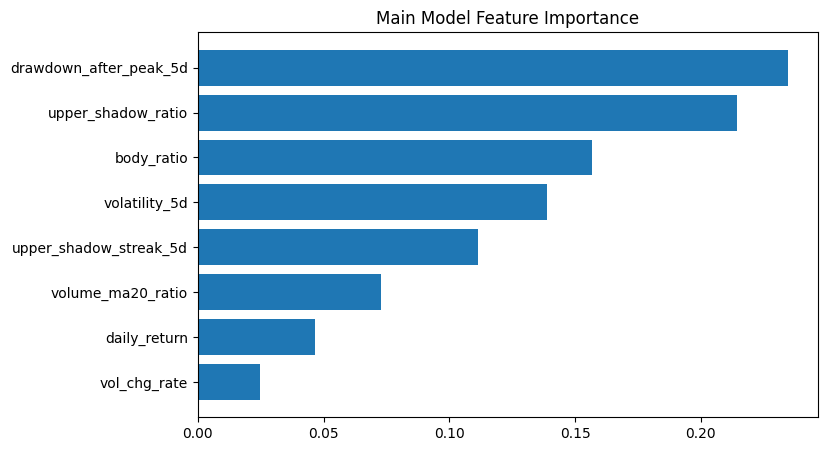

In [107]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Main Model Feature Importance"
)

plt.show()

## Main_Model version 2 : Isolation Forest + KMmeans


In [93]:
# ============================================================
# Main Model V2
# Isolation Forest + KMeans
# Step 1. IF 97% Anomaly Extraction
# ============================================================

main_v2_train = train_df.copy()
main_v2_valid = valid_df.copy()
main_v2_test  = test_df.copy()

main_v2_features = common_cluster_features

# 기존에 학습한 main_scaler, main_iforest 사용 가능
# IF score 계산
main_v2_train["if_score"] = -main_iforest.decision_function(
    X_main_train_scaled
)

main_v2_valid["if_score"] = -main_iforest.decision_function(
    X_main_valid_scaled
)

main_v2_test["if_score"] = -main_iforest.decision_function(
    X_main_test_scaled
)

# Train 기준 97% threshold
main_v2_threshold = main_v2_train["if_score"].quantile(0.97)

print("Main V2 IF Threshold:", main_v2_threshold)

# 동일 threshold 적용
main_v2_train["if_anomaly"] = (
    main_v2_train["if_score"] >= main_v2_threshold
).astype(int)

main_v2_valid["if_anomaly"] = (
    main_v2_valid["if_score"] >= main_v2_threshold
).astype(int)

main_v2_test["if_anomaly"] = (
    main_v2_test["if_score"] >= main_v2_threshold
).astype(int)

main_v2_anomaly_train = main_v2_train[
    main_v2_train["if_anomaly"] == 1
].copy()

main_v2_anomaly_valid = main_v2_valid[
    main_v2_valid["if_anomaly"] == 1
].copy()

main_v2_anomaly_test = main_v2_test[
    main_v2_test["if_anomaly"] == 1
].copy()

print("Train IF anomaly:", main_v2_anomaly_train.shape)
print("Valid IF anomaly:", main_v2_anomaly_valid.shape)
print("Test IF anomaly :", main_v2_anomaly_test.shape)

Main V2 IF Threshold: 0.07419706603321813
Train IF anomaly: (1272, 19)
Valid IF anomaly: (140, 19)
Test IF anomaly : (163, 19)


In [94]:
# ============================================================
# Main Model V2
# Step 2. KMeans K Tuning
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_main_v2_train = main_scaler.transform(
    main_v2_anomaly_train[main_v2_features]
)

main_v2_k_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_main_v2_train)

    sil = silhouette_score(
        X_main_v2_train,
        labels
    )

    main_v2_k_results.append({
        "k": k,
        "silhouette": sil,
        "anomaly_count": len(main_v2_anomaly_train)
    })

main_v2_k_results = pd.DataFrame(main_v2_k_results)

display(
    main_v2_k_results.sort_values(
        "silhouette",
        ascending=False
    )
)

,k,silhouette,anomaly_count
1,3,0.468105,1272
0,2,0.459381,1272
5,7,0.426439,1272
6,8,0.413181,1272
4,6,0.400367,1272
3,5,0.371687,1272
2,4,0.353302,1272


In [99]:
# ============================================================
# Main Model V2
# Step 3. Final KMeans Training
# ============================================================

main_v2_final_k = 2

main_v2_kmeans = KMeans(
    n_clusters=main_v2_final_k,
    random_state=42,
    n_init=10
)

main_v2_anomaly_train["cluster"] = main_v2_kmeans.fit_predict(
    X_main_v2_train
)

main_v2_train_silhouette = silhouette_score(
    X_main_v2_train,
    main_v2_anomaly_train["cluster"]
)

print("Train Silhouette:", round(main_v2_train_silhouette, 4))

print("\n[Train Cluster Count]")
print(
    main_v2_anomaly_train["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_train_profile = (
    main_v2_anomaly_train
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_train_profile)

Train Silhouette: 0.4594

[Train Cluster Count]
cluster
0    1083
1     189
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.164,10.463,0.031,0.056,0.144,0.140,3.597,1.825
1,0.736,0.131,0.000,0.000,-0.339,-13.255,13.749,0.000


In [100]:
# ============================================================
# Main Model V2
# Step 4. Validation Evaluation
# ============================================================

X_main_v2_valid = main_scaler.transform(
    main_v2_anomaly_valid[main_v2_features]
)

main_v2_anomaly_valid["cluster"] = main_v2_kmeans.predict(
    X_main_v2_valid
)

main_v2_valid_silhouette = silhouette_score(
    X_main_v2_valid,
    main_v2_anomaly_valid["cluster"]
)

print("Validation Silhouette:", round(main_v2_valid_silhouette, 4))

print("\n[Validation Cluster Count]")
print(
    main_v2_anomaly_valid["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_valid_profile = (
    main_v2_anomaly_valid
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_valid_profile)

Validation Silhouette: 0.3388

[Validation Cluster Count]
cluster
0    132
1      8
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.142,5.769,0.043,0.092,0.112,-0.157,0.978,1.0
1,0.518,-0.183,0.000,0.000,-0.312,-6.146,6.671,0.0


In [101]:
# ============================================================
# Main Model V2
# Step 5. Test Evaluation
# ============================================================

X_main_v2_test = main_scaler.transform(
    main_v2_anomaly_test[main_v2_features]
)

main_v2_anomaly_test["cluster"] = main_v2_kmeans.predict(
    X_main_v2_test
)

main_v2_test_silhouette = silhouette_score(
    X_main_v2_test,
    main_v2_anomaly_test["cluster"]
)

print("Test Silhouette:", round(main_v2_test_silhouette, 4))

print("\n[Test Cluster Count]")
print(
    main_v2_anomaly_test["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_test_profile = (
    main_v2_anomaly_test
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_test_profile)

Test Silhouette: 0.3957

[Test Cluster Count]
cluster
0    162
1      1
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,3.032,3.675,0.048,0.106,0.143,0.036,0.901,1.451
1,0.379,-0.403,0.000,0.000,-0.192,-10.370,10.656,0.000


In [102]:
# ============================================================
# Main Model V2
# Final Summary
# ============================================================

main_v2_summary = pd.DataFrame({
    "Dataset": ["Train", "Valid", "Test"],
    "Silhouette": [
        main_v2_train_silhouette,
        main_v2_valid_silhouette,
        main_v2_test_silhouette
    ],
    "Anomaly Count": [
        len(main_v2_anomaly_train),
        len(main_v2_anomaly_valid),
        len(main_v2_anomaly_test)
    ]
})

display(main_v2_summary)

,Dataset,Silhouette,Anomaly Count
0,Train,0.459381,1272
1,Valid,0.338811,140
2,Test,0.395653,163
